<a href="https://colab.research.google.com/github/irsotarriva/MLIdeas/blob/main/ImageGenerationLatentSpace1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This projects aims to generata a small simple image generation using a limited number of labels.

The idea came up as I was thinking different ways to substitute diffusion models. This is just a test of concept and if it works the next step would be test it with maybe a pretrained text vector encoder as the reference for the latent space and a image encoder-decoder trained to mimic the same vector space

In [1]:
# ============================================================
# 1. Setup
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data: MNIST normalized to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 497kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.72MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.59MB/s]


In [2]:
# ============================================================
# 2. Encoder and Decoder Networks
# ============================================================

latent_dim = 32

class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), # 14x14 -> 7x7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
    def forward(self, x):
        return self.conv(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 64 * 7 * 7),
            nn.ReLU()
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            nn.Tanh()  # Output in [-1, 1]
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 64, 7, 7)
        return self.deconv(x)

encoder = Encoder(latent_dim).to(device)
decoder = Decoder(latent_dim).to(device)

In [3]:
# ============================================================
# 3. Loss functions
# ============================================================

def reconstruction_loss(x, x_hat):
    return F.mse_loss(x_hat, x)

def separation_loss(z, labels):
    """
    Encourage same-class embeddings to be close, different-class embeddings to be far.
    """
    z_norm = F.normalize(z, dim=1)
    sim_matrix = torch.mm(z_norm, z_norm.T)
    label_matrix = labels.unsqueeze(1) == labels.unsqueeze(0)
    same_mask = label_matrix.float()
    diff_mask = 1 - same_mask

    same_sim = (1 - sim_matrix) * same_mask
    diff_sim = F.relu(0.5 - sim_matrix) * diff_mask  # push apart if too close

    loss_same = same_sim.sum() / (same_mask.sum() + 1e-6)
    loss_diff = diff_sim.sum() / (diff_mask.sum() + 1e-6)
    return loss_same + loss_diff

def smoothness_loss(decoder, z):
    """
    Encourage local smoothness: small latent perturbations shouldn't drastically change reconstructions.
    """
    eps = torch.randn_like(z) * 0.05
    x1 = decoder(z)
    x2 = decoder(z + eps)
    return F.mse_loss(x1, x2)

In [4]:
# ============================================================
# 4. Training loop
# ============================================================

optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)

epochs = 20

for epoch in range(epochs):
    encoder.train(); decoder.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        z = encoder(x)
        x_hat = decoder(z)

        loss_recon = reconstruction_loss(x, x_hat)
        loss_sep = separation_loss(z, y)
        loss_smooth = smoothness_loss(decoder, z)

        loss = loss_recon + 0.1 * loss_sep + 0.05 * loss_smooth

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss / len(train_loader):.4f}")

Epoch [1/20] Loss: 0.1387
Epoch [2/20] Loss: 0.0456
Epoch [3/20] Loss: 0.0330
Epoch [4/20] Loss: 0.0279
Epoch [5/20] Loss: 0.0248
Epoch [6/20] Loss: 0.0231
Epoch [7/20] Loss: 0.0216
Epoch [8/20] Loss: 0.0205
Epoch [9/20] Loss: 0.0197
Epoch [10/20] Loss: 0.0192
Epoch [11/20] Loss: 0.0186
Epoch [12/20] Loss: 0.0182
Epoch [13/20] Loss: 0.0177
Epoch [14/20] Loss: 0.0175
Epoch [15/20] Loss: 0.0172
Epoch [16/20] Loss: 0.0170
Epoch [17/20] Loss: 0.0167
Epoch [18/20] Loss: 0.0166
Epoch [19/20] Loss: 0.0164
Epoch [20/20] Loss: 0.0163


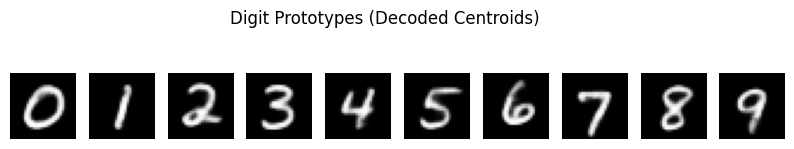

In [5]:
# ============================================================
# 5. Visualize results
# ============================================================

encoder.eval(); decoder.eval()

# Encode all training data to compute centroids
embeddings = []
labels = []
with torch.no_grad():
    for x, y in train_loader:
        z = encoder(x.to(device))
        embeddings.append(z.cpu())
        labels.append(y)
embeddings = torch.cat(embeddings)
labels = torch.cat(labels)

# Compute centroids for each label
centroids = {}
for i in range(10):
    centroids[i] = embeddings[labels == i].mean(0)

# Decode centroids to see prototypes
plt.figure(figsize=(10, 2))
for i in range(10):
    img = decoder(centroids[i].unsqueeze(0).to(device)).cpu().squeeze().detach()
    plt.subplot(1, 10, i+1)
    plt.imshow((img + 1)/2, cmap='gray')
    plt.axis('off')
plt.suptitle("Digit Prototypes (Decoded Centroids)")
plt.show()

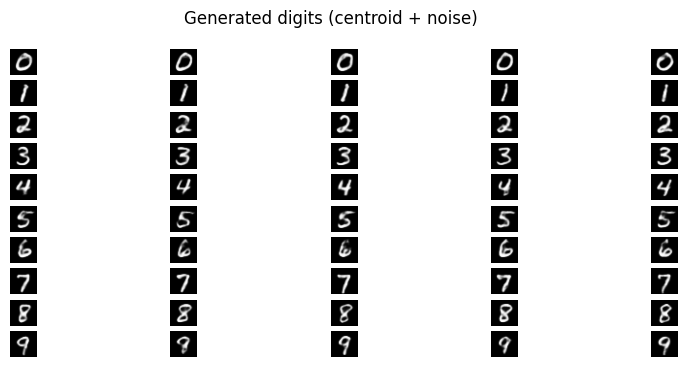

In [8]:
# ============================================================
# 6. Generation with noise around centroids
# Instead of the model generating the most likely image of a given label it will generate explore the space near the most likely image and generate plausible images similar to that one.
# ============================================================
temperature = 0.5
plt.figure(figsize=(10, 4))
for i in range(10):
    centroid = centroids[i].to(device)
    for j in range(5):
        z = centroid + torch.randn_like(centroid) * temperature
        img = decoder(z.unsqueeze(0)).cpu().squeeze().detach()
        plt.subplot(10, 5, i*5 + j + 1)
        plt.imshow((img + 1)/2, cmap='gray')
        plt.axis('off')
plt.suptitle("Generated digits (centroid + noise)")
plt.show()

In [7]:
# ============================================================
# 7. Validation accuracy by latent–centroid similarity
# ============================================================

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# (Optional) reload your model here if running standalone:
# encoder = Encoder(latent_dim).to(device)
# decoder = Decoder(latent_dim).to(device)
# encoder.load_state_dict(torch.load("encoder.pth"))
# decoder.load_state_dict(torch.load("decoder.pth"))
# encoder.eval(); decoder.eval()

# Compute centroids again if not in memory
if "centroids" not in locals():
    embeddings = []
    labels = []
    with torch.no_grad():
        for x, y in train_loader:
            z = encoder(x.to(device))
            embeddings.append(z.cpu())
            labels.append(y)
    embeddings = torch.cat(embeddings)
    labels = torch.cat(labels)

    centroids = {}
    for i in range(10):
        centroids[i] = embeddings[labels == i].mean(0)

# Convert centroids to matrix
centroid_matrix = torch.stack([centroids[i] for i in range(10)]).to(device)

# Evaluate classification accuracy
correct = 0
total = 0
encoder.eval()

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        z = encoder(x)                       # Encode images
        z_norm = F.normalize(z, dim=1)
        centroids_norm = F.normalize(centroid_matrix, dim=1)
        # Compute cosine similarity to each centroid
        sims = torch.mm(z_norm, centroids_norm.T)
        preds = sims.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

accuracy = 100 * correct / total
print(f"Validation accuracy (centroid classifier): {accuracy:.2f}%")


Validation accuracy (centroid classifier): 87.99%
